# Preparing training data and train an AI model



## Learning goals
- Prepare training data
- Use napari to clean up annotations
- Use public imaging data to train an AI model
# based on https://github.com/IDR/idr-notebooks/

Public repositories like IDR and BIA contain a lot of public data that can be used to train AI models.

IDR data can be explored via a public OMERO instance.

We will use some images part of a large Cell Paining screen.
The images consists of several markers. In this case we would like to use a different channel than the DAPI channel to segment the nuclei. This would allow in a new study to use the DAPI channel for another marker.

We can use the DAPI channel available in thedata to create ground-truth segmentations.

Explore data here https://idr.openmicroscopy.org/webclient/?show=image-1895787

## Setup

In [ ]:
IDR_BASE_URL = "https://idr.openmicroscopy.org"
MAP_URL = "{base}/webclient/api/annotations/?type=map&{type}={screen_id}"
PLATES_URL = "{base}/webclient/api/plates/?id={screen_id}"

SCREEN_ID = 1952

In [ ]:
# Explore data
from IPython.display import display, HTML
import requests
# initial data

In [2]:
INDEX_PAGE = f"{IDR_BASE_URL}/webclient/?experimenter=-1"
# create http session
with requests.Session() as session:
    request = requests.Request('GET', INDEX_PAGE)
    prepped = session.prepare_request(request)
    response = session.send(prepped)
    if response.status_code != 200:
        response.raise_for_status()

In [ ]:
# Now we can print the metadata available on this screen
qs = {'base': IDR_BASE_URL, 'type': 'screen', 'screen_id': SCREEN_ID}
url = MAP_URL.format(**qs)
for a in session.get(url).json()['annotations']:
    namespace = a['ns']
    for v in a['values']:
        key = v[0]
        value = v[1]
        print(key, value)


Sample Type cell
Organism Homo sapiens
Study Title Human U2OS cells - compound-profiling Cell Painting experiment
Study Type high content screen
Screen Type primary screen
Screen Technology Type compound screen
Imaging Method fluorescence microscopy
Publication Title Multiplex cytological profiling assay to measure diverse cellular states.
Publication Authors Gustafsdottir SM, Ljosa V, Sokolnicki KL, Anthony Wilson J, Walpita D, Kemp MM, Petri Seiler K, Carrel HA, Golub TR, Schreiber SL, Clemons PA, Carpenter AE, Shamji AF
PubMed ID 24312513 https://www.ncbi.nlm.nih.gov/pubmed/24312513
PMC ID PMC3847047 https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3847047
Publication DOI 10.1371/journal.pone.0080999 https://doi.org/10.1371/journal.pone.0080999
Release Date 2017-09-22
License CC0 1.0 https://creativecommons.org/publicdomain/zero/1.0/
Copyright Waived by Anne Carpenter
External URL https://www.broadinstitute.org/bbbc/BBBC022/
External URL http://www.cellimagelibrary.org/pages/project_202

In [40]:
qs = {'base': IDR_BASE_URL, 'screen_id': SCREEN_ID}
url = PLATES_URL.format(**qs)
for p in session.get(url).json()['plates']:
    plate_id = p['id']
    print("Plate: {id}, Name: {name}, Children: {childCount}".format(**p))



Plate: 4403, Name: 20585, Children: 0
Plate: 5352, Name: 20586, Children: 0
Plate: 4705, Name: 20589, Children: 0
Plate: 4881, Name: 20590, Children: 0
Plate: 4883, Name: 20591, Children: 0
Plate: 4884, Name: 20592, Children: 0
Plate: 4886, Name: 20593, Children: 0
Plate: 4887, Name: 20594, Children: 0
Plate: 4889, Name: 20595, Children: 0
Plate: 4890, Name: 20596, Children: 0
Plate: 4892, Name: 20607, Children: 0
Plate: 4893, Name: 20608, Children: 0
Plate: 4895, Name: 20625, Children: 0
Plate: 4896, Name: 20626, Children: 0
Plate: 4898, Name: 20630, Children: 0
Plate: 4899, Name: 20633, Children: 0
Plate: 4900, Name: 20639, Children: 0
Plate: 4902, Name: 20640, Children: 0
Plate: 4903, Name: 20641, Children: 0
Plate: 4905, Name: 20646, Children: 0


In [5]:
WELLS_IMAGES_URL = "{base}/webgateway/plate/{plate_id}/{field}/"

qs = {'base': IDR_BASE_URL, 'plate_id': plate_id, 'field': 0}
url = WELLS_IMAGES_URL.format(**qs)
grid = session.get(url).json()
rowlabels = grid['rowlabels']
collabels = grid['collabels']
for row in grid['grid']:
    for cell in row:
        if cell is not None:
            print("Well: {wellId}, Image: {id}".format(**cell))

Well: 1088876, Image: 2038821
Well: 1088604, Image: 2039821
Well: 1088577, Image: 2039578
Well: 1088696, Image: 2040649
Well: 1088735, Image: 2041000
Well: 1088562, Image: 2039443
Well: 1088702, Image: 2040703
Well: 1088496, Image: 2038849
Well: 1088540, Image: 2039245
Well: 1088625, Image: 2040010
Well: 1088593, Image: 2039722
Well: 1088628, Image: 2040037
Well: 1088608, Image: 2039857
Well: 1088759, Image: 2041216
Well: 1088623, Image: 2039992
Well: 1088685, Image: 2040550
Well: 1088548, Image: 2039317
Well: 1088686, Image: 2040559
Well: 1088746, Image: 2041099
Well: 1088783, Image: 2041432
Well: 1088717, Image: 2040838
Well: 1088780, Image: 2041405
Well: 1088679, Image: 2040496
Well: 1088564, Image: 2039461
Well: 1088645, Image: 2040190
Well: 1088607, Image: 2039848
Well: 1088603, Image: 2039812
Well: 1088513, Image: 2039002
Well: 1088510, Image: 2038975
Well: 1088742, Image: 2041063
Well: 1088770, Image: 2041315
Well: 1088676, Image: 2040469
Well: 1088716, Image: 2040829
Well: 1088

In [ ]:
# Now we can print the metadata available on a particular image
IMAGE_ID = 1898190
qs = {'base': IDR_BASE_URL, 'type': 'image', 'screen_id': IMAGE_ID}
url = MAP_URL.format(**qs)
for a in session.get(url).json()['annotations']:
    namespace = a['ns']
    for v in a['values']:
        key = v[0]
        value = v[1]
        print(key, value)

Cell Line U2OS
Compound Name ML9
Compound Name URL https://www.ncbi.nlm.nih.gov/pccompound?term=ML9
Compound Broad Identifier BRD-K68402494-001-04-7
Compound Broad Identifier URL https://pubchem.ncbi.nlm.nih.gov/compound/BRD-K68402494-001-04-7
Compound Broad Identifier Short BRD-K68402494
Compound Source Biomol International Inc.
Compound SMILES Clc1cccc2c(cccc12)S(=O)(=O)N3CCCNCC3
PubChem InChIKey OZSMSRIUUDGTEP-UHFFFAOYSA-N
Dose 7.70 micromolar
Organism Homo sapiens
Channels Hoechst 33342:nucleus;concanavalin A (con A) AlexaFluor488 conjugate:endoplasmic reticulumn;SYTO 14 green fluorescent nucleic acid stain:nucleoli;wheat germ agglutinin (WGA) AlexaFluor594 conjugate:Golgi apparatus and plasma membrane;phalloidin AlexaFluor594 conjugate:F-actin;MitoTracker Deep Red: mitochondria
In Annotated Set yes
GO Annotation GO:0004697 (inhibits protein kinase C activity)


In [43]:
annotations = session.get(url).json()['annotations']

meta = {k: v for a in annotations for k, v in a["values"]}

channels = [c.split(":", 1) for c in meta["Channels"].split(";")]
channels = {i: (dye.strip(), target.strip()) for i, (dye, target) in enumerate(channels)}

for i, (dye, target) in channels.items():
    print(i, dye, "->", target)


0 Hoechst 33342 -> nucleus
1 concanavalin A (con A) AlexaFluor488 conjugate -> endoplasmic reticulumn
2 SYTO 14 green fluorescent nucleic acid stain -> nucleoli
3 wheat germ agglutinin (WGA) AlexaFluor594 conjugate -> Golgi apparatus and plasma membrane
4 phalloidin AlexaFluor594 conjugate -> F-actin
5 MitoTracker Deep Red -> mitochondria


In [ ]:
# Pick one image, get channels names

IMAGE_DETAILS_URL = "{base}/api/v0/m/images/{image_id}/"
IMAGE_ID = 1898190

qs = {'base': IDR_BASE_URL, 'image_id': IMAGE_ID}
url = IMAGE_DETAILS_URL.format(**qs)

r = session.get(url).json()

# Images backed by OME-Zarr will link to the zarr data via the image externalInfo
image_details = r["data"]["omero:details"]
is_zarr = "externalInfo" in image_details and image_details["externalInfo"]["EntityType"] == "com.glencoesoftware.ngff:multiscales"

print("Is Zarr?", is_zarr)
zarr_url = None
if (is_zarr):
    externalInfo_lsid = image_details["externalInfo"]["Lsid"]
    print(externalInfo_lsid)
    zarr_url = externalInfo_lsid.replace("s3:", "https:").replace("?anonymous=true", "")
    zarr_url = zarr_url.rstrip("/")
    display(HTML(f"Open <a href='https://ome.github.io/ome-ngff-validator/?source={zarr_url}'>image in NGFF-validator</a>"))



Is Zarr? True
s3://livingobjects.ebi.ac.uk/bioimaging-integrator-data/S-BIAD855/781ac3d7-673f-47be-a4d2-3fdf3f477047/781ac3d7-673f-47be-a4d2-3fdf3f477047.zarr/B/2/8?anonymous=true


In [27]:
data = None
if zarr_url:
    import zarr
    import dask.array as da
    img_group = zarr.open(zarr_url)
    attrs = img_group.attrs.asdict()
    ds_paths = [ds["path"] for ds in attrs["multiscales"][0]["datasets"]]
    print("dataset paths", ds_paths)

    # Load dask array for smallest (last) dataset resolution
    data = da.from_zarr(f"{zarr_url}/{ds_paths[-3]}")
    # T, C, Z, Y, X
    print("array shape", data.shape)

dataset paths ['0', '1', '2', '3']
array shape (5, 260, 348)


extra_dims [2]
(260, 348)


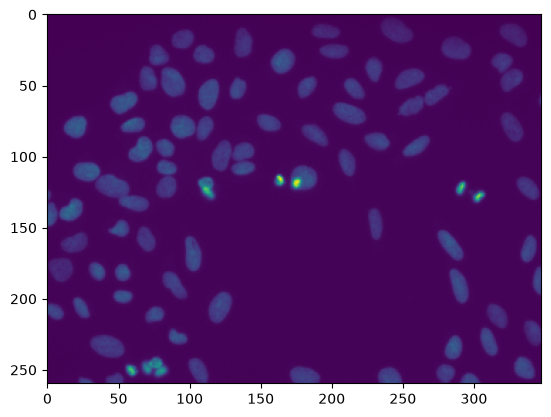

In [28]:
from matplotlib.pyplot import imshow
%matplotlib inline

if data is not None:
    # load the first plane (z, c, t = 0)
    extra_dims = [2] * (data.ndim - 2)
    print("extra_dims", extra_dims)
    # we slice away any Z/C/T dims, leaving Y and X
    to_slice = (*extra_dims, slice(None), slice(None))
    plane = data[to_slice]
    print(plane.shape)
    # plane is a 2D numpy array
    imshow(plane)



plane shape (260, 348)
otsu threshold: 470


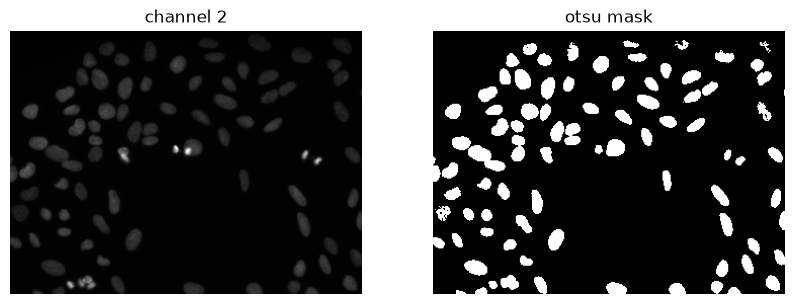

In [29]:
#Apply thresholding on one channel to create a mask
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

# data is T, C, Z, Y, X -> pick one channel, first timepoint and z-slice
CHANNEL = 2
img = np.asarray(plane)
print("plane shape", img.shape)

thresh = threshold_otsu(img)
mask = img > thresh
print("otsu threshold:", thresh)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"channel {CHANNEL}")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("otsu mask")
for ax in axes:
    ax.axis("off")


number of nuclei: 80


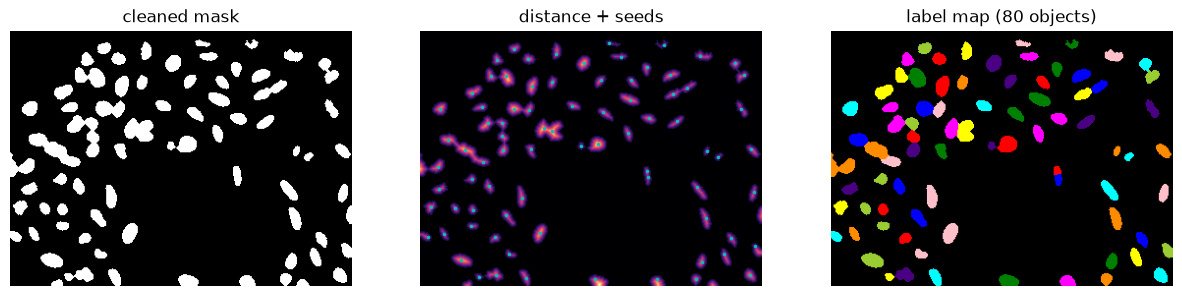

In [ ]:
# Split touching nuclei with a watershed and turn the mask into a label map
from scipy import ndimage as ndi
from skimage.morphology import remove_small_objects, closing, disk
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.color import label2rgb

# 1. clean up the binary mask
clean = closing(mask, disk(2))
clean = ndi.binary_fill_holes(clean)
clean = remove_small_objects(clean, max_size=50)   # drops objects <= 50 px

# 2. distance transform: local maxima sit in the middle of each nucleus
distance = ndi.distance_transform_edt(clean)
coords = peak_local_max(distance, min_distance=7, labels=clean)  # tune: ~nucleus radius
markers = np.zeros(distance.shape, dtype=int)
markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)

# 3. flood the inverted distance map from those markers
labels = watershed(-distance, markers, mask=clean)
print("number of nuclei:", labels.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(clean, cmap="gray")
axes[0].set_title("cleaned mask")
axes[1].imshow(distance, cmap="magma")
axes[1].plot(coords[:, 1], coords[:, 0], "c.", markersize=3)
axes[1].set_title("distance + seeds")
axes[2].imshow(label2rgb(labels, bg_label=0))
axes[2].set_title(f"label map ({labels.max()} objects)")
for ax in axes:
    ax.axis("off")


images in plate: 384
subset: [2040082, 2039029, 2040838, 2038876, 2040055, 2039785, 2041009, 2042062, 2039893, 2041144]
one image shape (C, Y, X): (5, 260, 348)


Text(0.5, 0.98, 'training input: channel 4')

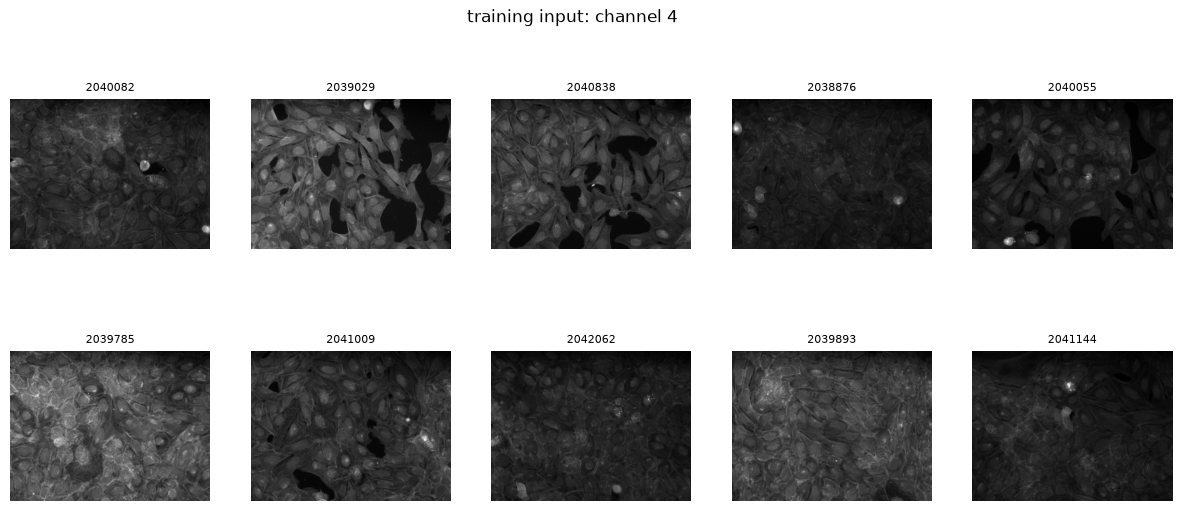

In [35]:
# Pick ~10 images from the plate to build a small training set
import random
import zarr
import dask.array as da

TRAIN_CHANNEL = 4    # last channel -> input for the network
NUCLEI_CHANNEL = 2   # channel we threshold to make the labels

# all image ids of the plate (from the well grid above)
image_ids = [c["id"] for row in grid["grid"] for c in row if c is not None]
print("images in plate:", len(image_ids))

random.seed(0)  # same subset every run
subset = random.sample(image_ids, 10)
print("subset:", subset)


def load_image(image_id, resolution=-3):
    """Load an IDR image as a dask array (lowest resolution by default)."""
    url = IMAGE_DETAILS_URL.format(base=IDR_BASE_URL, image_id=image_id)
    lsid = session.get(url).json()["data"]["omero:details"]["externalInfo"]["Lsid"]
    zarr_url = lsid.replace("s3:", "https:").replace("?anonymous=true", "").rstrip("/")
    paths = [ds["path"] for ds in zarr.open(zarr_url).attrs.asdict()["multiscales"][0]["datasets"]]
    return da.from_zarr(f"{zarr_url}/{paths[resolution]}")


# raw[channel] -> 2D plane, so keep both channels per image
raw = [np.asarray(load_image(i)) for i in subset]
print("one image shape (C, Y, X):", raw[0].shape)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, img, image_id in zip(axes.ravel(), raw, subset):
    ax.imshow(img[TRAIN_CHANNEL], cmap="gray")
    ax.set_title(image_id, fontsize=8)
    ax.axis("off")
fig.suptitle(f"training input: channel {TRAIN_CHANNEL}")


In [36]:
# Save the training data: channel 4 as input image, watershed labels as ground truth
from pathlib import Path
import tifffile

OUT = Path("training_data")
(OUT / "images").mkdir(parents=True, exist_ok=True)
(OUT / "labels").mkdir(parents=True, exist_ok=True)


def segment_nuclei(plane, min_distance=7, max_size=50):
    """Otsu threshold + watershed (same steps as above), returns a label map."""
    mask = plane > threshold_otsu(plane)
    clean = closing(mask, disk(2))
    clean = ndi.binary_fill_holes(clean)
    clean = remove_small_objects(clean, max_size=max_size)
    distance = ndi.distance_transform_edt(clean)
    coords = peak_local_max(distance, min_distance=min_distance, labels=clean)
    markers = np.zeros(distance.shape, dtype=int)
    markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)
    return watershed(-distance, markers, mask=clean)


for image_id, img in zip(subset, raw):
    labels = segment_nuclei(img[NUCLEI_CHANNEL])
    tifffile.imwrite(OUT / "images" / f"{image_id}.tif", img[TRAIN_CHANNEL])
    tifffile.imwrite(OUT / "labels" / f"{image_id}.tif", labels.astype("uint16"))
    print(image_id, "->", labels.max(), "nuclei")

print("saved to", OUT.resolve())


2040082 -> 117 nuclei
2039029 -> 76 nuclei
2040838 -> 76 nuclei
2038876 -> 122 nuclei
2040055 -> 74 nuclei
2039785 -> 120 nuclei
2041009 -> 99 nuclei
2042062 -> 134 nuclei
2039893 -> 124 nuclei
2041144 -> 112 nuclei
saved to /var/home/maartenpaul/Documents/GitHub/NL-BioImageAnalysis-course2026/day_3/AItraining/training_data


In [38]:
# Check the training data in napari: nuclei channel with the saved labels on top
# install with: pip install "napari[all]"
import napari

print("image shapes:", {img.shape[-2:] for img in raw})  # stacking needs one common shape

nuclei = np.stack([img[NUCLEI_CHANNEL] for img in raw])
inputs = np.stack([img[TRAIN_CHANNEL] for img in raw])
# read the labels back from disk, so we check what was actually saved
label_stack = np.stack([tifffile.imread(OUT / "labels" / f"{i}.tif") for i in subset])

viewer = napari.Viewer()
viewer.add_image(nuclei, name=f"channel {NUCLEI_CHANNEL} (nuclei)", colormap="gray")
viewer.add_image(inputs, name=f"channel {TRAIN_CHANNEL} (input)", colormap="green",
                 blending="additive", visible=False)
viewer.add_labels(label_stack, name="segmentation", opacity=0.4)
viewer.dims.axis_labels = ("image", "y", "x")
# use the top slider to step through the 10 images and check each segmentation
napari.run()  # not needed if the notebook already runs %gui qt


image shapes: {(260, 348)}


In [39]:
# Fix labels by hand in napari (brush / fill / eraser on the "segmentation" layer),
# then run this cell to write the corrected labels back to disk.
# napari edits label_stack in place, so this works whether the viewer is still open or closed.
for image_id, labels in zip(subset, label_stack):
    tifffile.imwrite(OUT / "labels" / f"{image_id}.tif", labels.astype("uint16"))
    print(image_id, "->", np.unique(labels).size - 1, "nuclei")

print("labels updated in", (OUT / "labels").resolve())


2040082 -> 119 nuclei
2039029 -> 76 nuclei
2040838 -> 76 nuclei
2038876 -> 122 nuclei
2040055 -> 74 nuclei
2039785 -> 120 nuclei
2041009 -> 99 nuclei
2042062 -> 134 nuclei
2039893 -> 124 nuclei
2041144 -> 112 nuclei
labels updated in /var/home/maartenpaul/Documents/GitHub/NL-BioImageAnalysis-course2026/day_3/AItraining/training_data/labels
